# Figure 3 
### interaction btw Difficulty and popularity

### Load Difficulty Result for python 

In [1]:
diff_idx = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., 111110000): ")

print(f'Figure will be drawn based on the run_id_{diff_idx} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from lib.annotation.tools.Result_Prep import Result_Prep as Result_Prep_D


import lib.stats.chowtest as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
import lib.visualization.figure_setting as figure_setting
import statsmodels.formula.api as smf

mpl.rcParams.update(figure_setting.fig_setting)




In [3]:
rp_prep_diff = Result_Prep_D(diff_idx)
diff_df = rp_prep_diff.data_concat()

In [4]:
df = diff_df[['creationdate', 'id', 'result']].drop_duplicates()
ids = (
    (df.groupby('id')['result'].count() == 1)
    .reset_index(name='is_one')
    .query('is_one == True')['id']
)
result_df = df[df['id'].isin(ids)].copy()
result_df['result'] = result_df['result'].str.replace('<Difficulty Level>', '')

In [5]:
tmp = load_df('/mnt/hdd/mghan/so_data_availability/result/tag/run_id_100/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
df_tot = pd.merge(result_df, tmp, on = 'id')    

100%|██████████| 153/153 [00:06<00:00, 24.67it/s]


In [6]:
# extract top bottom tags list from target dataset
tag_tmp = tmp[tmp['id'].isin(ids)]
tag_list = list(tag_tmp[tag_tmp['cdate'] < "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index()\
                .sort_values(by = ['pct'], ascending=False)['tag'])
topic_num = int(len(tag_list)*0.2)
top_list = tag_list[:topic_num]
bot_list = tag_list[-topic_num:]

In [7]:
df_tot['rel_week'] = (pd.to_datetime(df_tot['creationdate']) - datetime(2022, 11, 30)).dt.days // 7

In [8]:
df_tot

,creationdate,id,result,cdate,tag,cnt,tot_cnt,pct,rel_week
0,2020-12-02,65101937,0,2020-12-02,list,1,1,1.00,-104
1,2020-12-02,65102854,1,2020-12-02,django,1,2,0.50,-104
2,2020-12-02,65102854,1,2020-12-02,django-rest-framework,1,2,0.50,-104
3,2020-12-02,65103014,1,2020-12-02,pytorch,1,1,1.00,-104
4,2020-12-02,65104102,1,2020-12-02,tensorflow,1,1,1.00,-104
...,...,...,...,...,...,...,...,...,...
78425,2025-11-25,79830073,0,2025-11-25,tkinter,1,1,1.00,155
78426,2025-11-25,79830183,1,2025-11-25,css,1,4,0.25,155
78427,2025-11-25,79830183,1,2025-11-25,plotly,1,4,0.25,155
78428,2025-11-25,79830183,1,2025-11-25,plotly-dash,1,4,0.25,155


In [9]:
df_tot[(df_tot['result'] == '0') & (df_tot['tag'].isin(top_list))]

,creationdate,id,result,cdate,tag,cnt,tot_cnt,pct,rel_week
0,2020-12-02,65101937,0,2020-12-02,list,1,1,1.000000,-104
7,2020-12-02,65106408,0,2020-12-02,rounding,1,1,1.000000,-104
15,2020-12-02,65110009,0,2020-12-02,pandas,1,3,0.333333,-104
16,2020-12-02,65110009,0,2020-12-02,dataframe,1,3,0.333333,-104
17,2020-12-02,65110009,0,2020-12-02,class,1,3,0.333333,-104
...,...,...,...,...,...,...,...,...,...
78365,2025-11-24,79828217,0,2025-11-24,flask,1,1,1.000000,155
78368,2025-11-24,79828485,0,2025-11-24,selenium-webdriver,1,2,0.500000,155
78369,2025-11-24,79828485,0,2025-11-24,spyder,1,2,0.500000,155
78377,2025-11-24,79828854,0,2025-11-24,spyder,1,1,1.000000,155


In [10]:
df_w_r = df_tot[['rel_week', 'result']].drop_duplicates().reset_index(drop=True)

In [11]:
def extract_df_for_tag_list(df, tag_list):
    df_tot['rel_week'] = (pd.to_datetime(df_tot['creationdate']) - datetime(2022, 11, 30)).dt.days // 7
    df_tag_tot = df_tot[df_tot['tag'].isin(tag_list)]
    df_tag_tot_pct = df_tag_tot.groupby(['rel_week'])['pct'].sum().reset_index(name = 'tot_pct')
    df_tag_result_pct = df_tag_tot.groupby(['rel_week', 'result'])['pct'].sum().reset_index(name = 'pct')
    df_tag_viz = pd.merge(df_tag_tot_pct, df_tag_result_pct, on = 'rel_week')
    df_tag_viz['ratio'] = df_tag_viz['pct']/df_tag_viz['tot_pct']*100

    df_week = df_tot[['rel_week', 'result']].drop_duplicates().sort_values(by = ['rel_week']).reset_index(drop=True)
    df_tag_viz = pd.merge(df_week, df_tag_viz, on = ['rel_week', 'result'], how = 'left')
    df_tag_viz['ratio'] = df_tag_viz['ratio'].fillna(0)
    return df_tag_viz

In [12]:
df_top_viz = extract_df_for_tag_list(df_tot, top_list)
df_bot_viz = extract_df_for_tag_list(df_tot, bot_list)

In [13]:
df_bot_viz

,rel_week,result,tot_pct,pct,ratio
0,-104,0,NaN,NaN,0.000000
1,-104,1,1.583333,1.333333,84.210526
2,-104,2,1.583333,0.250000,15.789474
3,-103,1,1.500000,0.750000,50.000000
4,-103,0,NaN,NaN,0.000000
...,...,...,...,...,...
775,154,0,NaN,NaN,0.000000
776,154,1,1.333333,1.000000,75.000000
777,155,0,NaN,NaN,0.000000
778,155,2,2.666667,1.333333,50.000000


In [14]:
def draw_regression(ax, x, y, st_chow,
                            F_stat_1, p_value_1, title,
                            panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # ── scatter plot 
    plot_gen = PlotGen()
    plot_gen.draw_scatter_plot(ax, x, y)

    
    # ── Before ChatGPT
    plot_gen.fill_confidence_interval(ax, x1, st_chow.y1_predict - st_chow.y1_conf_interval, st_chow.y1_predict + st_chow.y1_conf_interval
                                          , label=None, color = figure_setting.PALETTE['primary'])
    plot_gen.draw_line_plot(ax, x1, st_chow.y1_predict, label='Before ChatGPT', color=figure_setting.PALETTE['primary'])

    # ── After ChatGPT
    plot_gen.fill_confidence_interval(ax, x2, st_chow.y2_predict - st_chow.y2_conf_interval, st_chow.y2_predict + st_chow.y2_conf_interval
                                          , label=None, color = figure_setting.PALETTE['accent'])
    plot_gen.draw_line_plot(ax, x2, st_chow.y2_predict,
            label='After ChatGPT',
            color=figure_setting.PALETTE['accent'])
    
    # ── Overall fit 
    plot_gen.draw_line_plot(ax, x, st_chow.y_predict, label='Overall fit', color=figure_setting.PALETTE['neutral'], opt='overall')


    # ── virtical line for chatGPT release
    plot_gen.draw_vertical_line(ax, x=0, label=None)


    # ── set title with p-value
#     p_txt = '$p$ < 0.001' if p_value_1 < 0.001 else f'$p$ = {p_value_1:.3f}'
#     prefix = f'{panel_label}.  ' if panel_label else ''
#     title_text = f'{prefix} {title}  ({p_txt})'
    plot_gen.set_title_two_lines(ax, prefix=None, title_text=title, p_value=p_value_1, gap=0.04)

    # ── ticks
    plot_gen.set_spines(ax)

    # ── set x lim
    plot_gen.set_lims(ax, x, y)

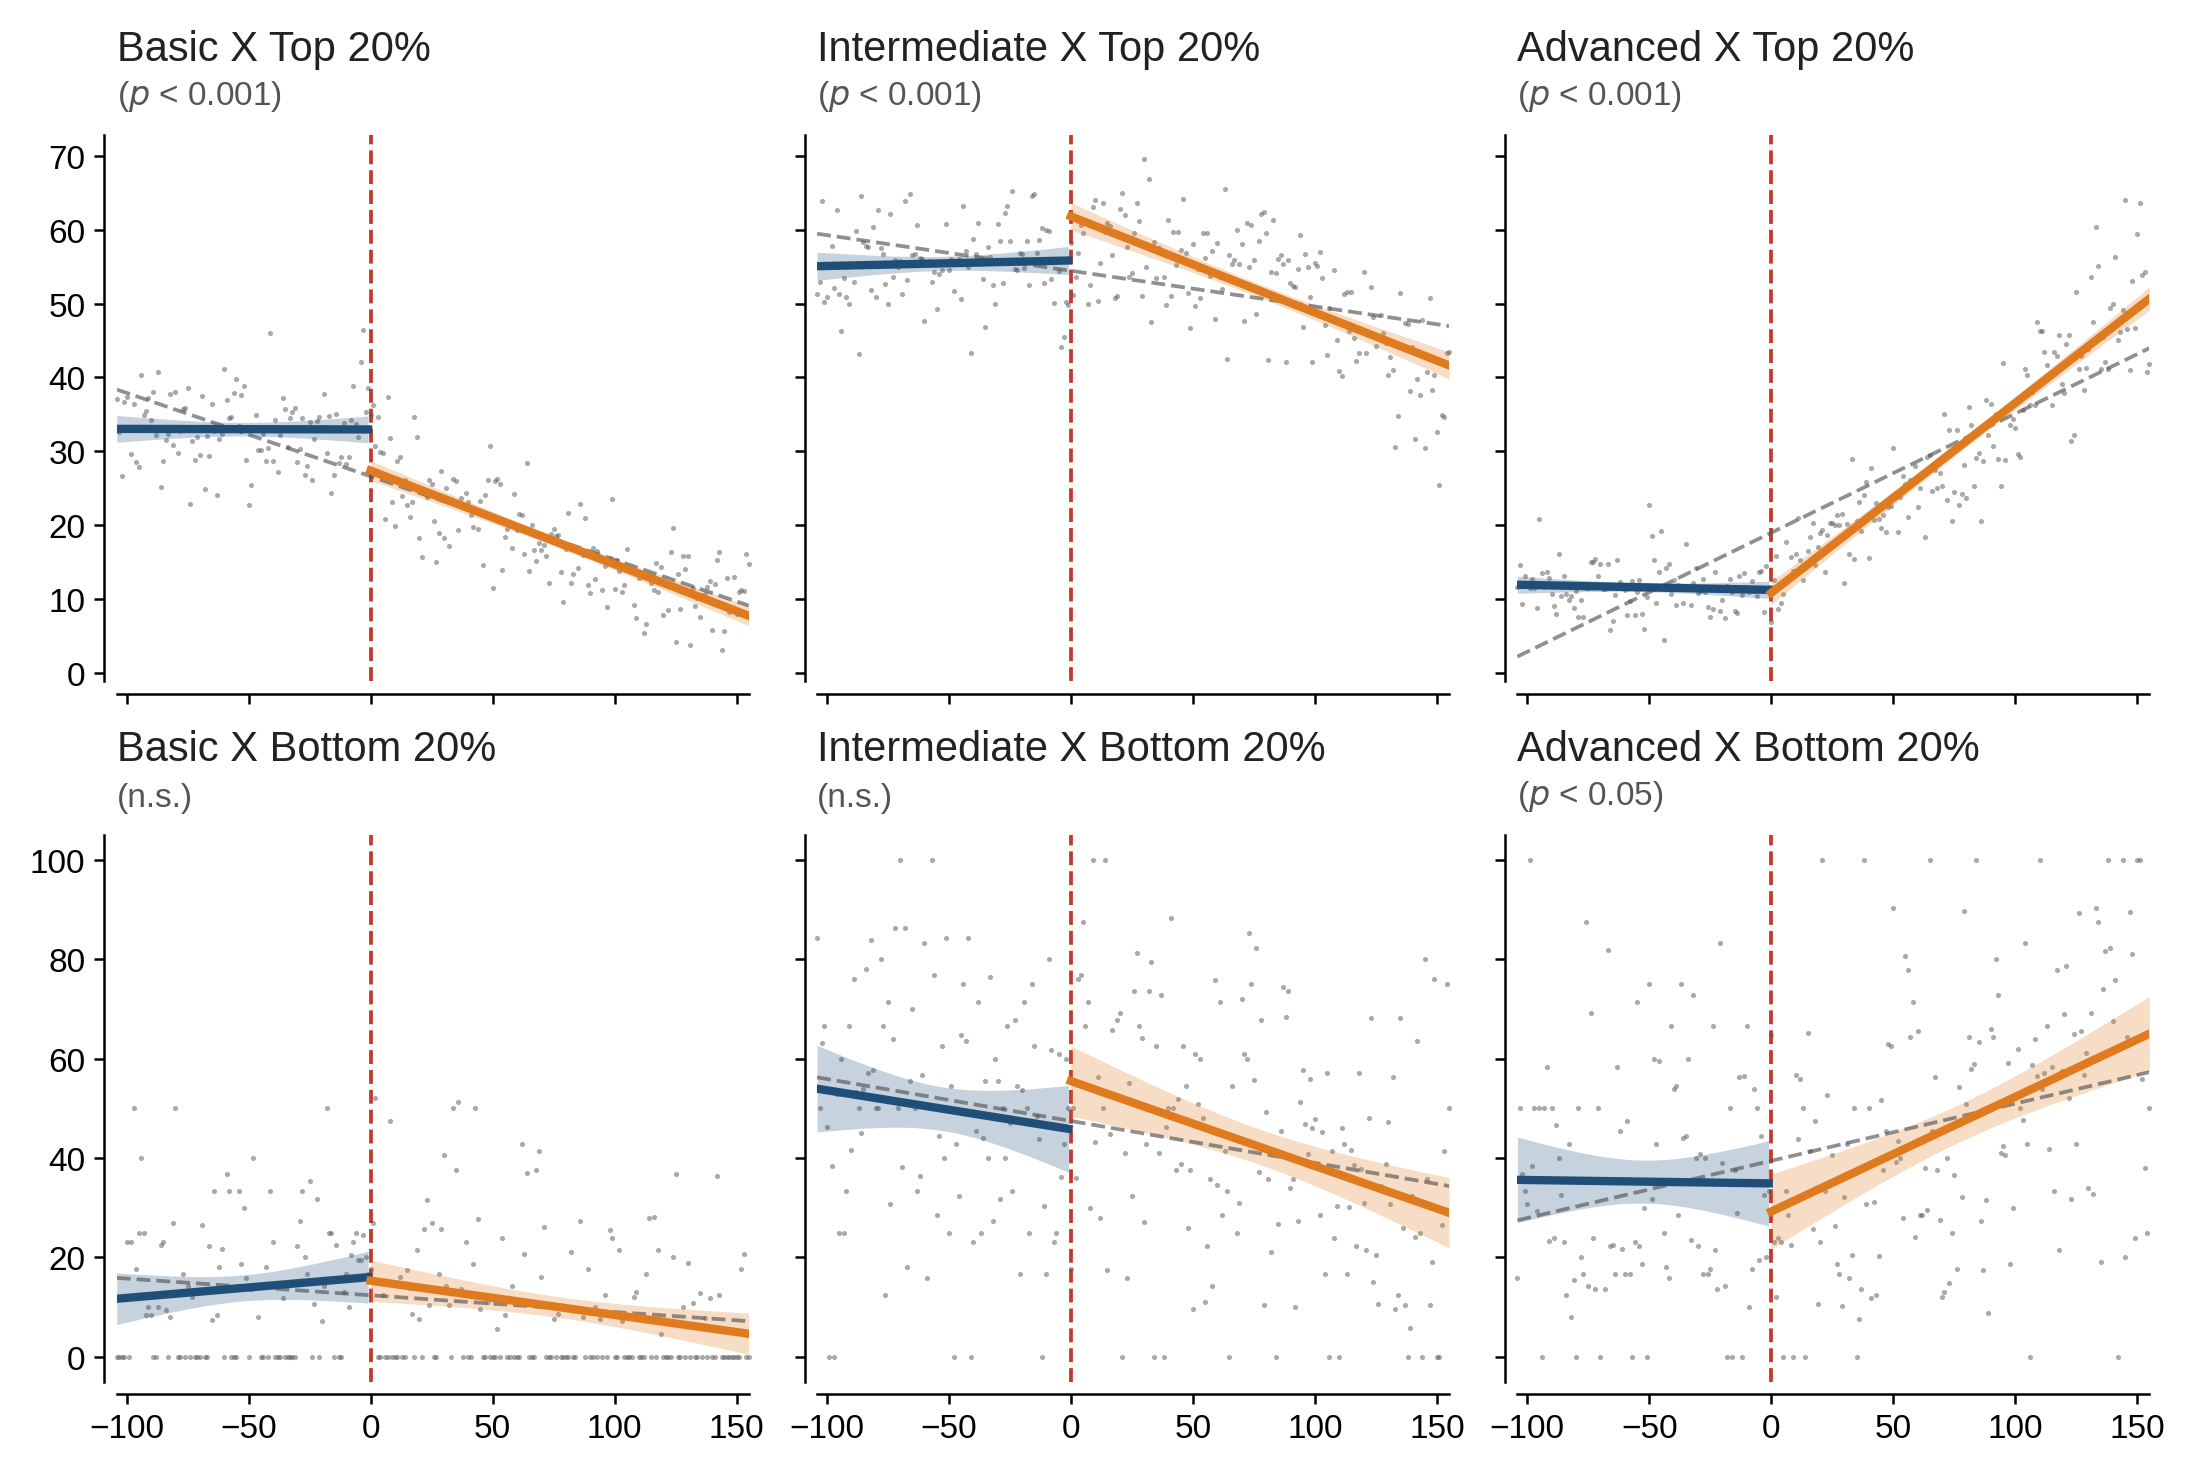

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8), dpi=300,
                         sharex=True, sharey='row',
                         constrained_layout=True)

panel_labels = [['A', 'B', 'C'], ['D', 'E', 'F']]
label_dict = {'0': 'Basic', '1': 'Intermediate', '2': 'Advanced'}
for j, r in enumerate(label_dict.keys()):
    top_sub = df_top_viz[df_top_viz['result'].astype(str) == r]
    top_x = top_sub['rel_week'].values
    top_y = top_sub['ratio'].values
    st_chow_top = st.ChowTest(top_x, top_y, 0.95, np.where(top_x < 0)[0][-1] + 1)
    F_stat_top, p_value_top = st_chow_top.chow_test()

    bot_sub = df_bot_viz[df_bot_viz['result'].astype(str) == r]
    bot_x = bot_sub['rel_week'].values
    bot_y = bot_sub['ratio'].values
    st_chow_bot = st.ChowTest(bot_x, bot_y, 0.95, np.where(bot_x < 0)[0][-1] + 1)
    F_stat_bot, p_value_bot = st_chow_bot.chow_test()

    draw_regression(axes[0, j], top_x, top_y, st_chow_top,
                            F_stat_top, p_value_top, f'{label_dict[r]} X Top 20%',
                            panel_label='')
                            # panel_label=panel_labels[0][j])
    draw_regression(axes[1, j], bot_x, bot_y, st_chow_bot,
                            F_stat_bot, p_value_bot, f'{label_dict[r]} X Bottom 20%',
                            panel_label='')
                            # panel_label=panel_labels[1][j])

plt.savefig('./fig/Fig3.pdf', bbox_inches='tight', dpi=300)

In [16]:
def its_effect(df, r, coef_name='time_post'):
    """
    ITS 회귀로 개입 효과 계수 + 95% CI 반환.
    coef_name='time_post' → 추세 변화 (Chow test와 일치)
    coef_name='post'      → 직후 수준 변화(점프)
    """
    sub = df[df['result'].astype(str) == r].copy()
    sub['time'] = sub['rel_week']
    sub['post'] = (sub['rel_week'] >= 0).astype(int)
    sub['time_post'] = sub['time'] * sub['post']

    model = smf.ols('ratio ~ time + post + time_post', data=sub).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 4}
    )


    coef = model.params[coef_name]
    ci_low, ci_high = model.conf_int().loc[coef_name]
    p = model.pvalues[coef_name]

    # errorbar용: 점에서 상/하한까지 거리
    err_low = coef - ci_low
    err_high = ci_high - coef
    return coef, err_low, err_high, p

top coef, 0 -0.12604377646282283
top coef, 1 -0.13768633996059917
top coef, 2 0.2637301164233387
bottom coef, 0 -0.11089464001778901
bottom coef, 1 -0.09250312390752281
bottom coef, 2 0.23759811527036961


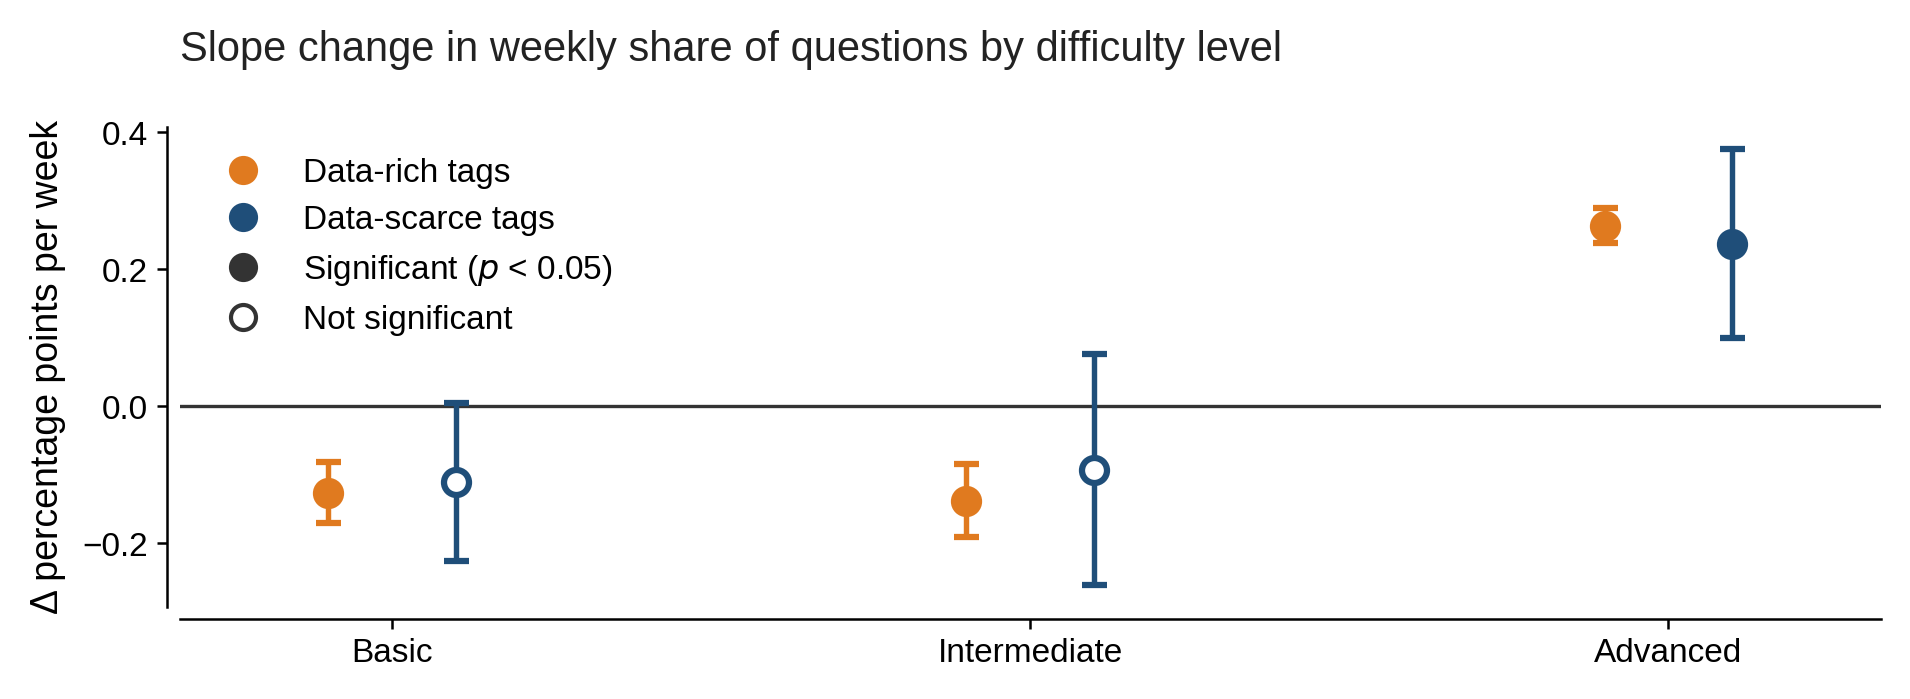

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 2.5), dpi=300)
label_dict = {'0': 'Basic', '1': 'Intermediate', '2': 'Advanced'}
level_keys = list(label_dict.keys())
level_names = list(label_dict.values())

# x_positions = np.arange(len(level_keys))
x_positions = np.array([0, 1.5, 3]) 

offset = 0.15
color_top = figure_setting.PALETTE['accent']    # 주황
color_bot = figure_setting.PALETTE['primary']   # 파랑


# 어떤 계수를 볼지: 'time_post'(추세 변화) 또는 'post'(수준 점프)
COEF = 'time_post'

# ── 0 기준선
ax.axhline(0, color='#333333', lw=0.8, zorder=1)

plotgen = PlotGen()
# ── Top 20%
for i, r in enumerate(level_keys):
    coef, e_low, e_high, p = its_effect(df_top_viz, r, COEF)
    print(f"top coef, {r}", coef)
    sig = p < 0.05
    plotgen.draw_errorbar(ax, x_positions[i] - offset, 
                     coef,
                     yerr   = [[e_low], [e_high]],
                     color  = color_top,
                     sig    = sig)

# ── Bottom 20%
for i, r in enumerate(level_keys):
    coef, e_low, e_high, p = its_effect(df_bot_viz, r, COEF)
    print(f"bottom coef, {r}", coef)
    sig = p < 0.05
    plotgen.draw_errorbar(ax, x_positions[i] + offset, 
                     coef,
                     yerr   = [[e_low], [e_high]],
                     color  = color_bot,
                     sig    = sig)

# ── 축
ax.set_xticks(x_positions)
ax.set_xticklabels(level_names)
ax.set_ylabel('Δ percentage points per week')
ax.set_xlim(-0.5, x_positions[-1] + 0.5) 
plotgen.set_title_two_lines(ax, prefix=None, title_text='Slope change in weekly share of questions by difficulty level',)

# ── 범례
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color=color_top, lw=0,
           markerfacecolor=color_top, markersize=6, label='Data-rich tags'),
    Line2D([0], [0], marker='o', color=color_bot, lw=0,
           markerfacecolor=color_bot, markersize=6, label='Data-scarce tags'),
    Line2D([0], [0], marker='o', color='#333333', lw=0,
           markerfacecolor='#333333', markersize=6, label='Significant ($p$ < 0.05)'),
    Line2D([0], [0], marker='o', color='#333333', lw=0,
           markerfacecolor='white', markeredgecolor='#333333',
           markersize=6, label='Not significant'),
]
ax.legend(handles=legend_elems, frameon=False, loc='best', fontsize=8)

# ── ticks
plotgen.set_spines(ax)

plt.tight_layout()
plt.savefig('./fig/Fig3_its.pdf', bbox_inches='tight', dpi=300)

In [18]:
def its_effect_linear(model, t_grid):
    """
    선형(linear-linear) ITS 모델에서 시점별 누적 효과 + delta method SE.
    effect(t) = β_post + β_time_post × t   (post 기간만, 절대 단위)
    """
    β_p, β_pt = model.params['post'], model.params['time_post']
    cov = model.cov_params()
    v_p, v_pt = cov.loc['post','post'], cov.loc['time_post','time_post']
    c_p_pt    = cov.loc['post','time_post']

    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2)*v_pt + 2*t_grid*c_p_pt, 0.0)
    se  = np.sqrt(np.maximum(var, 0))

    return pd.DataFrame({
        't': t_grid,
        'effect':      eff,                  # 절대 단위 (ratio 그대로)
        'ci_low':      eff - 1.96*se,
        'ci_high':     eff + 1.96*se,
    })

In [19]:
sub = df_bot_viz[df_bot_viz['result'].astype(str) == '0'].copy()
sub['time'] = sub['rel_week']
sub['post'] = (sub['rel_week'] >= 0).astype(int)
sub['time_post'] = sub['time'] * sub['post']

model = smf.ols('ratio ~ time + post + time_post', data=sub).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 4}
    )

# coef = model.params[coef_name]
# ci_low, ci_high = model.conf_int().loc[coef_name]
# p = model.pvalues[coef_name]

In [20]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  ratio   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     6.987
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           0.000155
Time:                        14:16:33   Log-Likelihood:                -1040.1
No. Observations:                 260   AIC:                             2088.
Df Residuals:                     256   BIC:                             2102.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.0667      2.901      5.538      0.000      10.380      21.753
time           0.0420      0.054      0.775      0.438      -0.064       0.148
post          -0.7359      3.799     -0.194      0.846      -8.181       6.709
time_post     -0.1109      0.059     -1.881      0.060      -0.226       0.005
==============================================================================
Omnibus:                       34.219   Durbin-Watson:                   1.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               43.967
Skew:                           0.993   Prob(JB):                     2.84e-10
Kurtosis:                       3.333   Cond. No.                         502.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 4 lags and without small sample correction
"""

In [21]:
model.conf_int()

,0,1
Intercept,10.380171,21.753263
time,-0.064205,0.148231
post,-8.180890,6.709043
time_post,-0.226470,0.004681
